In [1]:
from testflows.combinatorics import Covering
from matplotlib.ticker import MaxNLocator
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from sklearn import svm
import random
from sklearn.neighbors import KNeighborsClassifier
from numpy import inf
import time
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
import umap


d:\Tesis\icafs\icafs\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import opfython.math.general as g
import opfython.stream.parser as p
import opfython.stream.splitter as s
from opfython.models import SupervisedOPF
from opfython.stream import loader
from opfython.utils import logging

In [ ]:
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=500, n_informative = 4,n_features=10000, n_classes=2)

In [249]:
list_names = []
for i in range(0, X.shape[1]):
    column = f"Column {i}"
    list_names.append(column)

df_sintetic_x = pd.DataFrame(X, columns=list_names)
df_sintetic_y = pd.DataFrame(y, columns=['label'])


In [250]:
start_time = time.time()
iterations ,feature,score = ICAFS(df_sintetic_x,df_sintetic_y,2,10,'KNeighborsClassifier(n_neighbors=2)',True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'./output_images/sintetic_knn_icafs.png')

KeyboardInterrupt: 

Load data set

In [233]:
df_cis = pd.read_csv('../data/cis_data.csv')
df_cacao = pd.read_csv(r'..\\data\\data_temp\\cacao.csv')
df_algarrobo = pd.read_csv(r'..\\data\\data_temp\\algarrobo.csv')
df_fruits_pures = pd.read_csv(r'../data/data_temp/MIR_Fruit_purees.csv')
df_fresh_meat = pd.read_csv(r'../data/data_temp/Fresh_meats.csv')
df_olive = pd.read_csv(r'../data/data_temp/Olive_Oils_Quadrum.csv')


df_x_cacao = df_cacao.iloc[:, 1:]
y_cacao = df_cacao.iloc[:, 0:1]
X_cacao = (df_x_cacao-df_x_cacao.min())/(df_x_cacao.max()-df_x_cacao.min())

algarrobo_x = df_algarrobo.loc[:, 'R':'REDVI']
y_algarrobo = df_algarrobo['Labels'].replace(to_replace=['N', 'P'], value=[0, 1])
X_algarrobo = (algarrobo_x-algarrobo_x.min())/(algarrobo_x.max()-algarrobo_x.min())

cis_x = df_cis[['X', 'Y', 'X10', 'Y10', 'X20', 'Y20', 'X30', 'Y30', 'X40', 'Y40']]
y_cis = df_cis[['Result']]




unique_names_berry = df_fruits_pures["label"].unique()
fruits_pures_x = df_fruits_pures.iloc[:,1:]
y_fruit_puree = df_fruits_pures.iloc[:,0:1].replace(to_replace=unique_names_berry, value =range(0,len(unique_names_berry)))
X_fruit_puree = (fruits_pures_x-fruits_pures_x.min())/(fruits_pures_x.max()-fruits_pures_x.min())


unique_names_meat = df_fresh_meat["meat"].unique()
meat_x = df_fresh_meat.iloc[:,4:]
y_meat = df_fresh_meat.iloc[:,0:1].replace(to_replace=unique_names_meat,value=range(0,len(unique_names_meat)))
X_meat =  (meat_x-meat_x.min())/(meat_x.max()-meat_x.min())

unique_names_olive = df_olive["Provenance"].unique()
olive_x = df_olive.iloc[:,3:]
y_olive = df_olive.iloc[:,2:3].replace(to_replace=unique_names_olive,value=range(0,len(unique_names_olive)))
X_olive =  (olive_x-olive_x.min())/(olive_x.max()-olive_x.min())

X_cis = (cis_x-cis_x.min())/(cis_x.max()-cis_x.min())

C:\Users\robma\AppData\Local\Temp\ipykernel_3504\3692233082.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_algarrobo = df_algarrobo['Labels'].replace(to_replace=['N', 'P'], value=[0, 1])
C:\Users\robma\AppData\Local\Temp\ipykernel_3504\3692233082.py:25: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_fruit_puree = df_fruits_pures.iloc[:,0:1].replace(to_replace=unique_names_berry, value =range(0,len(unique_names_berry)))
C:\Users\robma\AppData\Local\Temp\ipykernel_3504\3692233082.py:31: FutureWarning: Downcasting behavior i

In [234]:
def ICAFS(dataset_X, dataset_Y, strenght,max_iteartion,model, print_logs=False):

  max_it = 1 
  score_list = []
  featur_list = []
  iter_list = []
  
  v_variable = [0, 1]
  best_f1_score = float('-inf')
  max_iteartion_aux =  max_iteartion
  best_data_set = dataset_X.columns.values.copy()

  initial_test_training(score_list,iter_list,featur_list,dataset_X,dataset_Y,model)
  while max_iteartion_aux > 0:

      dict_parameters = {}
      partial_best_list = []
      partial_score = 0
      for colum_key in best_data_set:
          dict_parameters[colum_key] = v_variable
      random.shuffle(best_data_set)
      generate_covering_array = Covering(dict_parameters, strength=strenght)
      for test in generate_covering_array.array:
          list_attributes_to_consider = []

          check_for_all_cero = True
          for (test_key, test_value) in test.items():
              if test_value == 1:
                  check_for_all_cero = False
                  list_attributes_to_consider.append(test_key)

          if check_for_all_cero:
              continue  
          df_temp = dataset_X[list_attributes_to_consider]
          clf_new = train_model(model)
          score = cross_val_score(clf_new,df_temp.values, dataset_Y.values.ravel(), cv=5, scoring='f1_macro')
          final_score = score.mean()

          if final_score >= partial_score :
              partial_score = final_score
              partial_best_list = list_attributes_to_consider
          clf_new = None
      best_data_set = partial_best_list.copy()
      best_f1_score = partial_score
      
      if print_logs:
        print(f"best f1 score= {best_f1_score}, iteration:{max_it}, numbers features selected ={ len(best_data_set)},best features selected={', '.join(best_data_set)}" )

      iter_list.append(max_it)
      aux_data_score = best_f1_score
      score_list.append(aux_data_score)
      max_iteartion_aux = max_iteartion_aux-1
      max_it = max_it +1
      featur_list.append(len(best_data_set))
  return iter_list,featur_list,score_list

def initial_test_training(score_list, iter_list, feature_list ,X,y,model):
     X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(X.values, y.values.ravel(), test_size=0.20, random_state=42)
     clf_new = train_model(model)
     clf_new.fit(X_train_temp, y_train_temp)
     y_pred = clf_new.predict(X_test_temp)
     score_list.append(f1_score(y_test_temp, y_pred,average='macro'))
     feature_list.append(X.shape[1])
     iter_list.append(0)

def train_model(model_name):  
    m = eval(model_name)
    return m

In [235]:
def  plot_results_for_covering_array(scores,feature,num_of_iterarion, path_to_save_image):
        color = 'tab:blue'
        res_scores = np.array(scores)
        res_features = np.array(feature)
        res_iter = np.array(num_of_iterarion)

        plt.figure(figsize=(11, 10))
        
        fig, ax1 = plt.subplots()
        barwidth = 0.4
        color = 'tab:red'
        ax1.set_xlabel('Iterations')
        ax1.set_ylabel('Number of features', color=color)
        #ax1.set_title("ICAFS Feature selection on the Cacao dataset")
        ax1.spines['top'].set_visible(False)
        ax1.bar(res_iter-0.2, res_features, color=color, width=barwidth)
        ax1.tick_params(axis='y', labelcolor=color,labelrotation=45)
        ax1.set_ylim(1,max(res_features)+3)
        ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
        
        for bar in ax1.patches:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width() / 2.0, height, f' {height}', fontsize=10,
                    ha='center', va='bottom', rotation=90)
            
        ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis
        color = 'tab:blue'
        ax2.set_ylabel('F1_score', color=color)
        ax2.bar(res_iter+0.2, res_scores, color=color, width=barwidth)
        ax2.tick_params(axis='y', labelcolor=color,labelrotation=45)
        ax2.set_ylim(min(res_scores)-0.001, max(res_scores)+0.001)

        fig.tight_layout()  # otherwise the right y-label is slightly clipped
       
        for bar in ax2.patches:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width() / 2.0, height, f' {height:.2f}', fontsize=10,
                    ha='center', va='bottom', rotation=90)

        #plt.title('ICAFS Feature selection for Cacao Dataset with OPF', y=-0.20)
        plt.gca().set_frame_on(False)
        plt.savefig(path_to_save_image)

In [236]:

from mpl_toolkits import mplot3d
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler


def plot_original_vs_reduced_umap(df_reduced_dataset,df_complete, y_dataset_integer,unique_classes):
    umap_3d = umap.UMAP(n_components=3)
    
    X_reduced_standarized = StandardScaler().fit_transform(df_reduced_dataset)
    X_complete_standarized  = StandardScaler().fit_transform(df_complete)
    
    reduced_umap = umap_3d.fit_transform(X_reduced_standarized)
    complete_umap = umap_3d.fit_transform(X_complete_standarized)
  
    fig = plt.figure(figsize=plt.figaspect(0.5))
    y_dataset_flatten = y_dataset_integer.values.ravel()

    print(unique_classes)
    ax = fig.add_subplot(1, 2, 1, projection='3d')
    for i in range(0,len(unique_classes)): 
        indices = np.where(y_dataset_flatten == i)
        ax.scatter(complete_umap[indices,0], complete_umap[indices,1], complete_umap[indices,2], c=sns.color_palette()[i],marker = "v", label=unique_classes[i])
    plt.legend()
    #ax.scatter(complete_umap[:,0], complete_umap[:,1], complete_umap[:,2], c=[sns.color_palette()[x] for x in y_dataset_flatten],marker = "v",label=unique_classes[0])
    
    ax = fig.add_subplot(1, 2, 2, projection='3d')
    for i in range(0,len(unique_classes)): 
        indices = np.where(y_dataset_flatten == i)
        ax.scatter(reduced_umap[indices,0], reduced_umap[indices,1], reduced_umap[indices,2], c=sns.color_palette()[i],marker = "v", label=unique_classes[i])

    #ax.scatter(reduced_umap[:,0], reduced_umap[:,1], reduced_umap[:,2], c=[sns.color_palette()[x] for x in y_dataset_flatten],marker = "v",label=unique_classes[0])
    plt.legend()
    
    plt.show()
   

ICAFS KNN

In [140]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_cacao,y_cacao,2,10,'KNeighborsClassifier(n_neighbors=2)',True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'./output_images/cacao_knn_icafs.png')

KeyboardInterrupt: 

best f1 score= 0.7351370100315423, iteration:1, numbers features selected =9,best features selected=NGRDI, NDVI, RVI, DVI, EVI, REVI, NDRE, RERVI, REDVI
best f1 score= 0.7216630322908072, iteration:2, numbers features selected =6,best features selected=NGRDI, NDVI, RVI, EVI, NDRE, REDVI
best f1 score= 0.717571263976013, iteration:3, numbers features selected =4,best features selected=NGRDI, NDVI, RVI, NDRE
best f1 score= 0.7092041147580356, iteration:4, numbers features selected =3,best features selected=NGRDI, NDVI, RVI
best f1 score= 0.7092041147580356, iteration:5, numbers features selected =3,best features selected=NGRDI, NDVI, RVI
best f1 score= 0.7092041147580356, iteration:6, numbers features selected =3,best features selected=NGRDI, NDVI, RVI
best f1 score= 0.7092041147580356, iteration:7, numbers features selected =3,best features selected=NGRDI, NDVI, RVI
best f1 score= 0.7092041147580356, iteration:8, numbers features selected =3,best features selected=NGRDI, NDVI, RVI
best 

<Figure size 1100x1000 with 0 Axes>

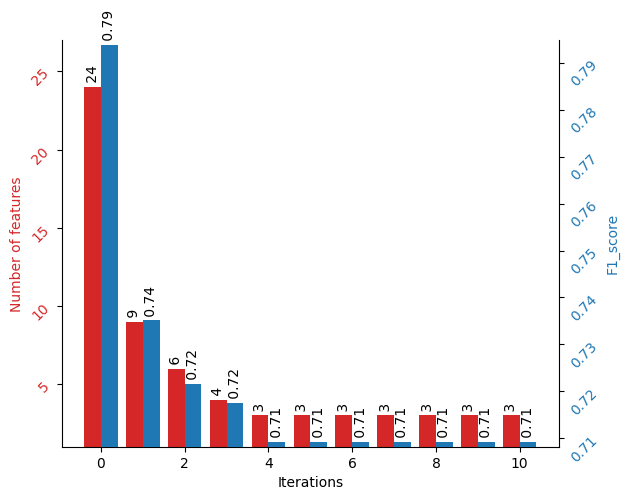

In [10]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_algarrobo,y_algarrobo,2,10,'KNeighborsClassifier(n_neighbors=3)',True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\algarrobo_knn_icafs.png')

best f1 score= 0.9571730048089891, iteration:1, numbers features selected =156,best features selected=907.047, 1018.987, 1026.707, 1030.567, 1034.427, 1038.287, 1042.147, 1046.007, 1049.867, 1053.727, 1057.587, 1061.447, 1065.307, 1069.167, 1073.027, 1076.887, 1080.747, 1084.607, 1088.467, 1092.327, 1096.187, 1100.047, 1103.907, 1107.767, 1111.627, 1115.487, 1119.347, 1123.207, 1127.067, 1130.927, 1134.786, 1138.646, 1142.506, 1146.366, 1150.226, 1154.086, 1157.946, 1161.806, 1165.666, 1169.526, 1173.386, 1177.246, 1181.106, 1184.966, 1188.826, 1192.686, 1196.546, 1200.406, 1204.266, 1208.126, 1211.986, 1215.846, 1219.706, 1223.566, 1227.426, 1231.286, 1235.146, 1239.006, 1242.866, 1246.726, 1250.586, 1254.446, 1258.306, 1262.166, 1266.026, 1269.886, 1273.746, 1277.606, 1281.466, 1285.326, 1289.186, 1293.046, 1296.906, 1300.766, 1304.626, 1308.486, 1312.346, 1316.206, 1320.066, 1323.926, 1327.786, 1331.646, 1335.506, 1339.366, 1343.226, 1347.086, 1350.946, 1354.806, 1358.666, 1362.526,

<Figure size 1100x1000 with 0 Axes>

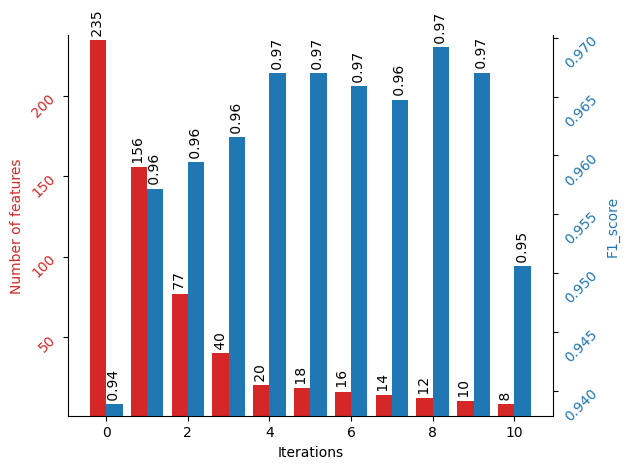

In [11]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_fruit_puree,y_fruit_puree,2,10,'KNeighborsClassifier(n_neighbors=3)',True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\fruit_puree_knn_icafs.png')

d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


['Not Strawberry' 'Strawberry']


C:\Users\robma\AppData\Local\Temp\ipykernel_3504\3654617813.py:24: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(complete_umap[indices,0], complete_umap[indices,1], complete_umap[indices,2], c=sns.color_palette()[i],marker = "v", label=unique_classes[i])
C:\Users\robma\AppData\Local\Temp\ipykernel_3504\3654617813.py:31: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(reduced_umap[indices,0], reduced_umap[

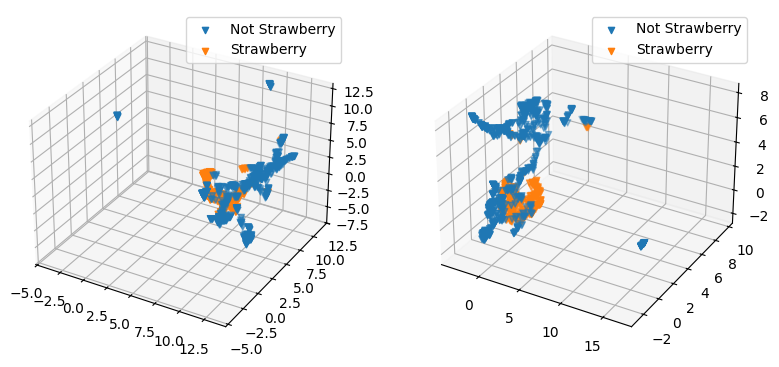

In [206]:
plot_original_vs_reduced_umap(X_fruit_puree[['1404.985', '1443.585', '1474.465', '1516.925', '1609.565', '1679.044', '1771.684', '1802.564']],X_fruit_puree,y_fruit_puree,unique_names_berry)

best f1 score= 0.9747027699968877, iteration:1, numbers features selected =270,best features selected=1018.856, 1344.9525, 1346.882, 1348.8115, 1350.741, 1352.6705, 1354.6, 1356.5295, 1358.459, 1360.3885, 1362.318, 1364.2485, 1366.178, 1368.1075, 1370.037, 1371.9665, 1375.8255, 1377.755, 1379.6845, 1381.614, 1383.5435, 1385.473, 1387.4025, 1389.332, 1391.2615, 1393.191, 1395.1205, 1397.05, 1398.9805, 1400.91, 1402.8395, 1404.769, 1406.6985, 1408.628, 1410.5575, 1412.487, 1414.4165, 1416.346, 1418.2755, 1420.205, 1422.1345, 1424.064, 1425.9935, 1427.923, 1429.8525, 1431.782, 1433.7125, 1435.642, 1437.5715, 1439.501, 1441.4305, 1443.36, 1445.2895, 1447.219, 1449.1485, 1451.078, 1453.0075, 1454.937, 1456.8675, 1458.797, 1460.7265, 1462.656, 1464.5855, 1468.4445, 1470.374, 1472.3035, 1474.233, 1476.1625, 1478.092, 1480.0215, 1481.951, 1483.8805, 1485.81, 1487.7395, 1489.669, 1491.5995, 1493.529, 1495.4585, 1499.3175, 1501.247, 1503.1765, 1505.106, 1507.0355, 1508.965, 1510.8945, 1512.824, 

<Figure size 1100x1000 with 0 Axes>

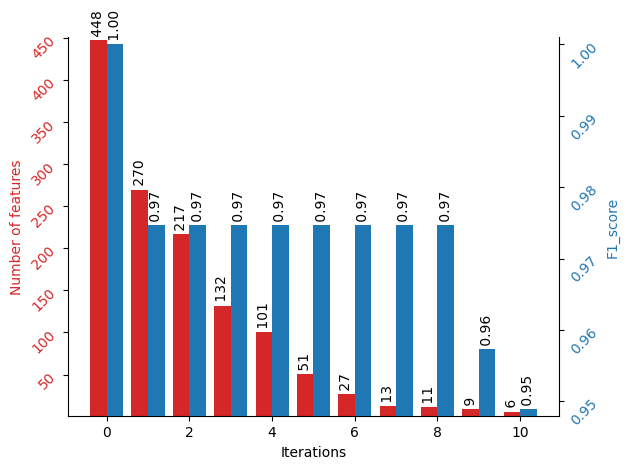

In [176]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_meat,y_meat,2,10,'KNeighborsClassifier(n_neighbors=3)',True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\meat_knn_icafs.png')

d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


['Chicken' 'Pork' 'Turkey']


C:\Users\robma\AppData\Local\Temp\ipykernel_3504\3654617813.py:24: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(complete_umap[indices,0], complete_umap[indices,1], complete_umap[indices,2], c=sns.color_palette()[i],marker = "v", label=unique_classes[i])
C:\Users\robma\AppData\Local\Temp\ipykernel_3504\3654617813.py:31: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(reduced_umap[indices,0], reduced_umap[

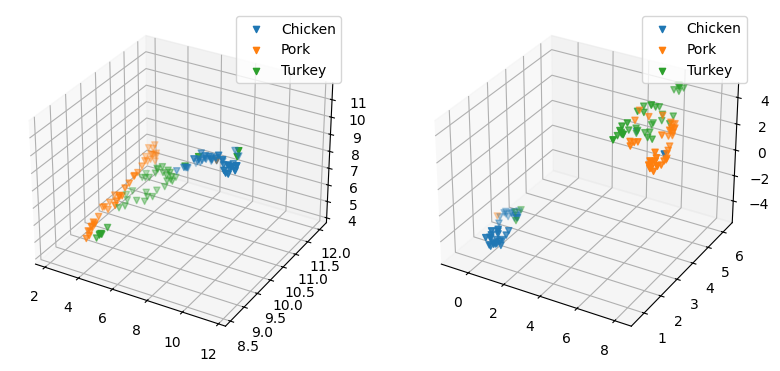

In [196]:
plot_original_vs_reduced_umap(X_meat[['1634.3875', '1713.499', '1719.2875', '1746.3015', '1836.991', '1842.7805']], X_meat,y_meat,unique_names_meat)

best f1 score= 0.8873252371123888, iteration:1, numbers features selected =287,best features selected=802.751, 827.8345, 831.6935, 833.623, 835.5525, 837.482, 839.4115, 841.341, 843.2705, 845.2, 847.1295, 849.059, 850.9885, 852.918, 854.8475, 856.777, 858.7065, 860.636, 868.354, 870.2835, 872.213, 876.072, 881.8605, 883.79, 885.7195, 887.649, 891.508, 893.4375, 895.367, 905.0145, 908.8735, 910.803, 920.4505, 928.1685, 930.098, 932.0275, 933.957, 937.816, 943.6045, 945.534, 947.4645, 949.394, 953.253, 955.1825, 957.112, 966.7595, 970.6185, 972.548, 974.4775, 982.1955, 989.9135, 991.843, 993.7725, 995.702, 999.561, 1007.279, 1009.2085, 1011.138, 1014.997, 1016.9265, 1018.856, 1028.5035, 1032.3625, 1034.292, 1036.2215, 1043.9405, 1051.6585, 1053.588, 1055.5175, 1057.447, 1061.306, 1069.024, 1070.9535, 1072.883, 1076.743, 1078.6725, 1080.602, 1090.2495, 1094.1085, 1096.038, 1097.9675, 1105.6855, 1113.4045, 1115.334, 1117.2635, 1119.193, 1123.052, 1130.77, 1132.7005, 1134.63, 1138.489, 1140

<Figure size 1100x1000 with 0 Axes>

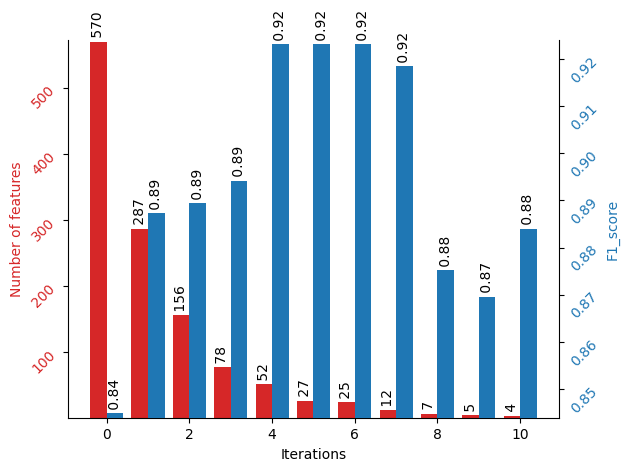

In [208]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_olive,y_olive,2,10,'KNeighborsClassifier(n_neighbors=2)',True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\olive_icafs.png')

d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\Tesis\icafs\icafs\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


['Greece' 'Italy' 'Portugal' 'Spain']


C:\Users\robma\AppData\Local\Temp\ipykernel_3504\3654617813.py:24: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(complete_umap[indices,0], complete_umap[indices,1], complete_umap[indices,2], c=sns.color_palette()[i],marker = "v", label=unique_classes[i])
C:\Users\robma\AppData\Local\Temp\ipykernel_3504\3654617813.py:31: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(reduced_umap[indices,0], reduced_umap[

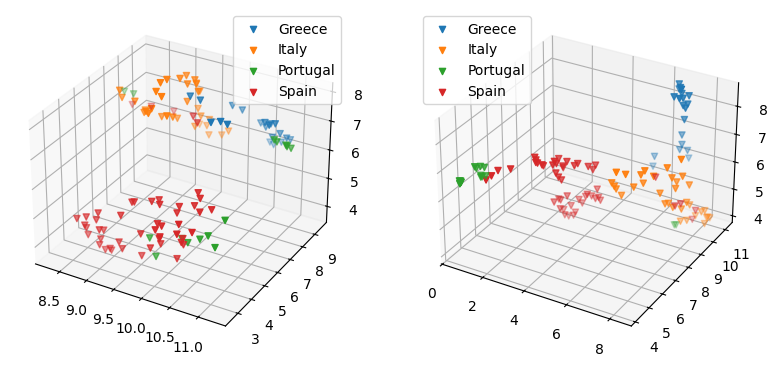

In [216]:
plot_original_vs_reduced_umap(X_olive[['974.4775', '1032.3625', '1130.77', '1617.021']],X_olive,y_olive,unique_names_olive)

In [ ]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_cis,y_cis,3,10,'KNeighborsClassifier(n_neighbors=3)',True)
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\cis_knn_icafs.png')

ICAFS OPF

In [ ]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_algarrobo,y_algarrobo,2,10,'SupervisedOPF(distance="log_squared_euclidean", pre_computed_distance=None)',True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\algarrobo_opf_icafs.png')

5 CV Algarrobo OPF

In [ ]:
from sklearn.model_selection import KFold

scores = []
kf = KFold(n_splits=5,shuffle=True, random_state =42)
X = X_algarrobo[[ 'NGRDI', 'NDVI', 'RVI', 'DVI', 'EVI', 'REVI', 'NDRE', 'RERVI', 'REDVI']]

for i, (train_index, test_index) in enumerate(kf.split(X.values)):
   
   x_fold_train = X.values[train_index,:]
   y_fold_train = y_algarrobo.values[train_index]

   x_fold_test =  X.values[test_index,:]
   y_fold_test = y_algarrobo.values[test_index]
   
   clf = SupervisedOPF(distance="log_squared_euclidean", pre_computed_distance=None)
   clf.fit(x_fold_train, y_fold_train)
   y_pred_fold = clf.predict(x_fold_test)
   score = f1_score(y_fold_test, y_pred_fold,average='macro')
   scores.append(score)

res = np.asarray(scores, dtype=np.float32)
print(f"5-CV Algarrobo OPF mean:{res.mean()} , 5-CV Algarrobo STD:{res.std()}" )

In [ ]:
start_time = time.time()
iterations ,feature,score  = ICAFS(X_cacao,y_cacao,2,10,'SupervisedOPF(distance="log_squared_euclidean", pre_computed_distance=None)',True )
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\cacao_opf_icafs.png')

5 CV Caco OPF

In [ ]:
from sklearn.model_selection import KFold

scores = []
kf = KFold(n_splits=5, shuffle=True, random_state =42)
X = X_cacao[['1542', '1611', '1836', '1930', '2398']]

for i, (train_index, test_index) in enumerate(kf.split(X.values)):
   
   x_fold_train = X.values[train_index,:]
   y_fold_train = y_cacao.values[train_index]

   x_fold_test =  X.values[test_index,:]
   y_fold_test = y_cacao.values[test_index]
   clf = SupervisedOPF(distance="log_squared_euclidean", pre_computed_distance=None)
   clf.fit(x_fold_train, y_fold_train)
   y_pred_fold = clf.predict(x_fold_test)
   score = f1_score(y_fold_test, y_pred_fold,average='macro')
   scores.append(score)

res = np.asarray(scores, dtype=np.float32)
print(f"5-CV Cacao OPF mean:{res.mean()} , 5-CV Cacao STD:{res.std()}" )

In [ ]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_cis,y_cis,3,4,'SupervisedOPF(distance="log_squared_euclidean", pre_computed_distance=None)',True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'./output_images/cis_opf_icafs.png')

5 CV OPF CIS

In [ ]:
from sklearn.model_selection import KFold

scores = []
kf = KFold(n_splits=5, shuffle=True, random_state =42)
X = X_cis[['X', 'Y', 'Y40']]

for i, (train_index, test_index) in enumerate(kf.split(X.values)):
   
   x_fold_train = X.values[train_index,:]
   y_fold_train = y_cis.values[train_index]

   x_fold_test =  X.values[test_index,:]
   y_fold_test = y_cis.values[test_index]
   clf = SupervisedOPF(distance="log_squared_euclidean", pre_computed_distance=None)
   clf.fit(x_fold_train, y_fold_train)
   y_pred_fold = clf.predict(x_fold_test)
   score = f1_score(y_fold_test, y_pred_fold,average='macro')
   scores.append(score)

res = np.asarray(scores, dtype=np.float32)
print(f"5-CV Cacao OPF mean:{res.mean()} , 5-CV Cacao STD:{res.std()}" )

ICAFS SVC

In [ ]:
start_time = time.time()
iterations ,feature,score  = ICAFS(X_cacao,y_cacao,2,10,'svm.SVC()' ,True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\cacao_svc_icafs.png')

In [ ]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_algarrobo,y_algarrobo,2,10,'svm.SVC()',True )
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\algarrobo_svc_icafs.png')

In [ ]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_fruit_puree,y_fruit_puree,2,10,'svm.SVC()',True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\fruit_puree_svc_icafs.png')

In [ ]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_cis,y_cis,3,10,'svm.SVC()',True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\cis_knn_icafs.png')

5 Cross Validation ICAFS CIS SVC

In [ ]:
clf = svm.SVC()
X = X_cis[['X', 'Y', 'Y40']]
res = cross_val_score(clf,X.values, y_cis.values.ravel(), cv=5,scoring = 'f1_macro')
print(f"5-CV CIS mean:{res.mean()} , 5-CV CIS STD:{res.std()}" )

ICAFS MLP

In [ ]:
start_time = time.time()
iterations ,feature,score  = ICAFS(X_cacao,y_cacao,2,10,'MLPClassifier(solver="sgd", max_iter=7000, shuffle=False)',True )
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\cacao_mlp_icafs.png')

ICAFS MLP CACAO 5 CV

In [ ]:
clf = MLPClassifier(solver="sgd", max_iter=7000, shuffle=False)
X = X_cacao[['1737', '1761', '1810', '1814', '1822', '1826', '1857', '1873', '1877', '1902', '1949', '1953', '1961', '1965', '1989', '2006', '2010', '2038', '2082', '2086', '2097', '2101', '2126', '2173', '2185', '2285', '2401', '2406', '2437']
]
res = cross_val_score(clf,X.values, y_cacao.values.ravel(), cv=5,scoring = 'f1_macro')
print(f"5-CV Cacao mean:{res.mean()} , 5-CV Cacao STD:{res.std()}" )

In [ ]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_algarrobo,y_algarrobo,2,10,'MLPClassifier(solver="sgd", max_iter=5000, shuffle=False)' ,True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\algarrobo_mlp_icafs.png')

ICAFS MLP Algarrobo 5 CV

In [ ]:
clf = MLPClassifier(solver="sgd", max_iter=5000, shuffle=False)
X = X_algarrobo[['GBRI.1', 'CIVE', 'MGRVI']]
res = cross_val_score(clf,X.values, y_algarrobo.values.ravel(), cv=5,scoring = 'f1_macro')
print(f"5-CV Algarrobo mean:{res.mean()} , 5-CV Algarrobo STD:{res.std()}" )

In [ ]:
start_time = time.time()
iterations ,feature,score = ICAFS(X_cis,y_cis,3,10,'MLPClassifier(solver="sgd", max_iter=5000, shuffle=False)',True)
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")
plot_results_for_covering_array(score,feature,iterations, r'.\\output_images\\cis_mlp_icafs.png')

ICAFS MLP CIS 5 CV

In [ ]:
clf = MLPClassifier(solver="sgd", max_iter=5000, shuffle=False)
X = X_cis[['X', 'Y', 'Y40']]
res = cross_val_score(clf,X.values, y_cis.values.ravel(), cv=5,scoring = 'f1_macro')
print(f"5-CV CIS mean:{res.mean()} , 5-CV CIS STD:{res.std()}" )